Netflix Content Analysis

Business Problem

Netflix has expanded rapidly over the years, offering thousands of movies and TV shows from different countries and genres. The objective of this project is to analyze the Netflix catalog to identify content trends, production patterns, and key characteristics of its library.

In [54]:
# Download Netflix dataset from Kaggle
import kagglehub

path = kagglehub.dataset_download("shivamb/netflix-shows")
print(path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
/kaggle/input/netflix-shows


In [55]:
import os

os.listdir(path)

['netflix_titles.csv']

In [56]:
#set the stage
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
df = pd.read_csv(
    path + "/netflix_titles.csv",
    encoding="latin1"
)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [58]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [59]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [60]:
df.shape[0]

8807

## Key Performance Indicators (KPIs)

Before exploring the content in detail, the following KPIs provide a high-level overview of Netflix's catalog.

These metrics summarize the size and composition of the platform before analyzing trends, genres, and geographic distribution.

In [72]:
total_titles = df.shape[0]

print(f"Total Titles: {total_titles}")

Total Titles: 8807


## Movies vs TV Shows

This analysis compares the number of Movies and TV Shows available on Netflix.

Understanding the distribution of content types helps identify Netflix's primary content strategy and how the platform allocates its catalog between films and episodic series.

In [61]:
movies_tv = df["type"].value_counts()

print(movies_tv)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


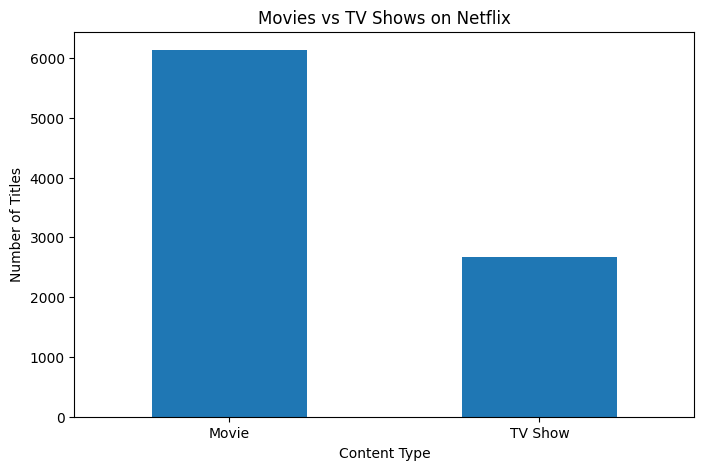

In [62]:
movies_tv.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.xticks(rotation=0)

plt.show()

### Business Insight

The analysis shows that Movies represent the majority of Netflix's catalog, indicating that films remain the platform's primary content offering. While TV Shows account for a smaller share, they continue to play an important role in attracting and retaining subscribers through serialized content.

### Most Common Rating

This KPI identifies the content rating that appears most frequently in Netflix's catalog, providing insight into the platform's target audience.

In [73]:
most_common_rating = df["rating"].mode()[0]

print(f"Most Common Rating: {most_common_rating}")

Most Common Rating: TV-MA


In [74]:
df["rating"].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


### Number of Countries Represented

Netflix offers content produced in many different countries. This KPI measures the geographic diversity of the catalog.

In [75]:
countries = (
    df["country"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .nunique()
)

print(f"Countries Represented: {countries}")

Countries Represented: 123


### Average Movie Duration

This KPI calculates the average duration of movies available on Netflix, providing a general overview of the platform's film catalog.

In [76]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = (
    movies["duration"]
    .str.replace(" min","", regex=False)
    .astype(float)
)

average_duration = movies["duration"].mean()

print(f"Average Movie Duration: {average_duration:.1f} minutes")

Average Movie Duration: 99.6 minutes


In [63]:
#Top 10 Countries
Top_countries = df["country"].value_counts()

print(Top_countries)

country
United States                                                      2818
India                                                               972
United Kingdom                                                      419
Japan                                                               245
South Korea                                                         199
                                                                   ... 
Mexico, United States, Spain, Colombia                                1
Canada, Norway                                                        1
Finland, Germany, Belgium                                             1
Argentina, United States, Mexico                                      1
United Kingdom, United States, Germany, Denmark, Belgium, Japan       1
Name: count, Length: 748, dtype: int64


In [64]:
df_countries = df["country"].dropna().str.split(", ").explode()

# Counting the values & showing the top ten
top_10 = df_countries.value_counts().head(10).reset_index()
top_10.columns = ["Country", "Count"]

# pie graph
fig = px.pie(
    top_10,
    values="Count",
    names="Country",
    title="Top 10 Countries",
    color_discrete_sequence=px.colors.sequential.RdBu,
)

fig.show()

In [65]:
#Top 10 Genres
df_generes = df["listed_in"].value_counts()

print(df_generes)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Action & Adventure, Cult Movies                       1
Action & Adventure, Comedies, Music & Musicals        1
Classic Movies, Horror Movies, Thrillers              1
Children & Family Movies, Classic Movies, Dramas      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64


In [66]:
df_generes = df["listed_in"].dropna().str.split(", ").explode()

# Counting the values & showing the top ten
top_10 = df_generes.value_counts().head(10).reset_index()
top_10.columns = ["Generes", "Count"]

# pie graph
fig = px.pie(
    top_10,
    values="Count",
    names="Generes",
    title="Top 10 Generes",
    color_discrete_sequence=px.colors.sequential.RdBu,
)

fig.show()

## Content Added per Year

This analysis examines how the number of titles added to Netflix has changed over time.

By analyzing yearly additions, we can identify periods of rapid catalog expansion, understand content acquisition trends, and observe how Netflix has evolved as a streaming platform.

In [68]:
#Content Added per Year
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed",
    errors="coerce"
)

In [70]:
content_per_year = (
    df.dropna(subset=["date_added"])
      .groupby(df["date_added"].dt.year)
      .size()
)

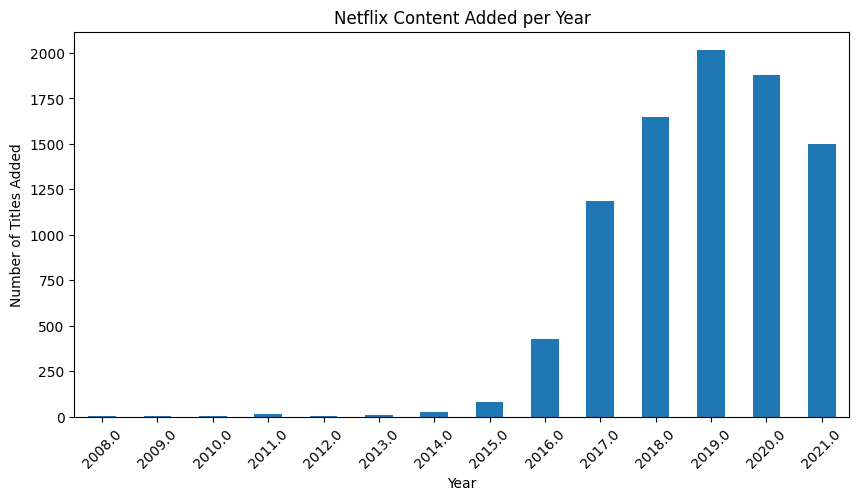

In [71]:
content_per_year.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Netflix Content Added per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.xticks(rotation=45)

plt.show()

## Ratings Distribution

Content ratings indicate the intended audience for Netflix titles.

This analysis examines how titles are distributed across different age ratings, helping identify the platform's primary target audience.

In [77]:
ratings = (
    df["rating"]
    .value_counts()
)

ratings

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


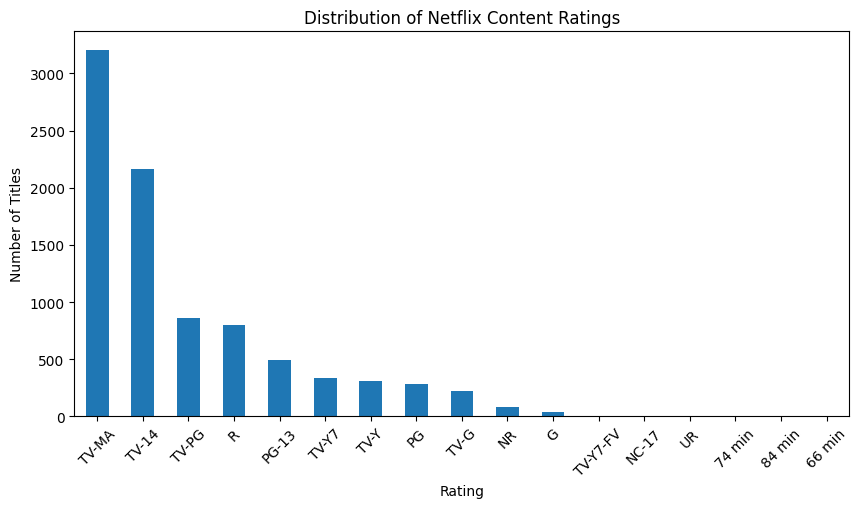

In [78]:
ratings.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Business Insight

The catalog is concentrated in a small number of content ratings, suggesting that Netflix primarily targets general and mature audiences while maintaining a diverse selection for younger viewers.

# Conclusions

The analysis provides an overview of Netflix's content strategy and catalog composition.

### Key Findings

- Movies represent the majority of Netflix's content.
- The United States contributes the largest number of titles.
- Drama and International Movies dominate the catalog.
- Netflix experienced significant catalog growth between 2016 and 2020.
- Most titles are targeted toward mature audiences.

### Future Work

Future improvements include:

- Country-level trend analysis
- Genre popularity over time
- Interactive Tableau dashboard
- Predictive content recommendation models